<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab #2: Linear Classifiers and Multilayer Perceptrons</h2>
Semester 1, 2026<br>
</center>


**Due**: 11:59pm on Sunday 8 March, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging. Note that this code will not be run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`).

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

In [1]:
# TODO: Replace with your name and university ID
student_name = "Rui Luo"
student_id = "u8076655"

## Disclosure

TODO: doucment any use of online resources (other than course material) and/or generative AI tools.

In [2]:
# The ANU lab machines will have python and the necessary packages already installed. If you're working
# on your own machine you will need to install python with Jupyter notebook, OpenCV and PyTorch:
#  - Documentation for the OpenCV computer vision library is here: https://opencv.org/. You should be able
#    to install the library on your computer using `pip install opencv-python` or if you have conda
#    `conda install conda-forge::opencv`.
#  - Documentation for the PyTorch deep learning library is here: https://pytorch.org/. Follow the
#    installation instructions (for the stable release, v2.9.1 at time of writing), being sure to install
#    both `pytorch` and `torchvision`. You will not need access to a GPU for this course but having one
#    may increase computation speed.
#  Browse through the user documentation and tutorials for these libraries.

import sys
import getpass

def is_notebook():
    return 'ipykernel' in sys.modules

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
if is_notebook():
    print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
    print("Python Version: {}".format(sys.version))
    print("PyTorch Version: {}".format(torch.__version__))

User: apple (Rui Luo, u8076655)
Python Version: 3.10.16 (main, Dec 11 2024, 10:24:41) [Clang 14.0.6 ]
PyTorch Version: 2.2.2


In [3]:
device = torch.device("cpu")
random_seed = 32426242
torch.manual_seed(random_seed)

In [4]:
# Preliminaries -- Generating an synthetic binary classification dataset that follows the XOR function 
# Conceptually, the 2D feature vectors can be seen as randomly generated points on a 2d plane
# and the corresponding labels denotes where the coordinates of the points have the same sign. 
def gen_xor_data(
    num_samples: int, train_ratio: float = 0.9
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Generate XOR data.

    Args:
        num_samples (int): number of samples to generate.

    Returns:
        tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]: tuple of (x_train, y_train, x_test, y_test) where x is the input data and y is the label.
    """
    x = torch.rand(num_samples, 2)
    y = torch.zeros(num_samples, dtype=torch.long)
    for i in range(num_samples):
        if x[i, 0] > 0.5:
            if x[i, 1] > 0.5:
                y[i] = 0
            else:
                y[i] = 1
        else:
            if x[i, 1] > 0.5:
                y[i] = 1
            else:
                y[i] = 0
    x -= 0.5
    num_train_data = int(len(x) * train_ratio)
    return x[:num_train_data], y[:num_train_data], x[num_train_data:], y[num_train_data:]


x_train, y_train, x_test, y_test = gen_xor_data(1000)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

(torch.Size([900, 2]),
 torch.Size([900]),
 torch.Size([100, 2]),
 torch.Size([100]))

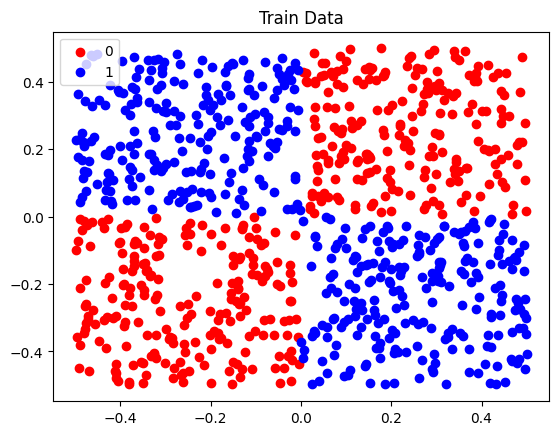

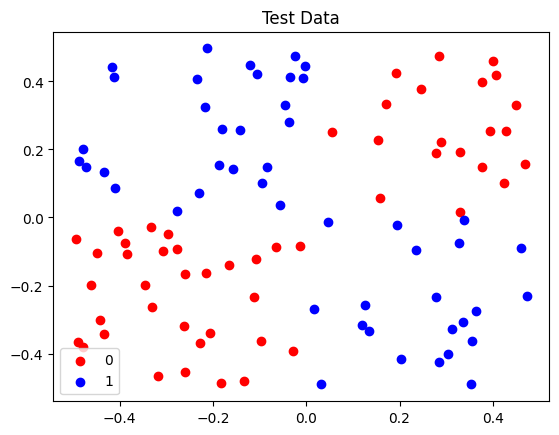

In [5]:
if is_notebook():# Visualise XOR data
    def visualize_xor_data(x: torch.Tensor, y: torch.Tensor, title: str = None):
        plt.scatter(x[y == 0, 0], x[y == 0, 1], color="red", label="0")
        plt.scatter(x[y == 1, 0], x[y == 1, 1], color="blue", label="1")
        plt.legend()
        if title:
            plt.title(title)
        plt.show()


    visualize_xor_data(x_train, y_train, "Train Data")
    visualize_xor_data(x_test, y_test, "Test Data")

## Task 1 -- Linear Forward 

In [6]:
# --- TASK 1 -----
# Implement an linear forward function 
# Given input x, weight matrix A and bias vector b, return the output y
def linear_forward(x: torch.Tensor, A: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """One forward pass of a single-layer perceptron (one linear layer).

    Args:
        x (torch.Tensor): The input to the linear layer, of shape (B, D).
        A (torch.Tensor): The weight matrix of the linear layer, of shape (H, D).
        b (torch.Tensor): The bias vector of the linear layer, of shape (H,).

    Returns:
        torch.Tensor: The output of the linear layer, needs to be in the shape of (B, H).

    Notes:
        Checkout PyTorch's implementation of `torch.nn.Linear`: https://pytorch.org/docs/stable/generated/torch.nn.Linear.html.
    """
    # TODO: implement the forward pass of a single-layer perceptron.
    
    # Shapes:
    #   x   : (B, D) — a batch of B input vectors, each of dimension D
    #   A   : (H, D) — H output neurons, each with D learnable weights
    #   A.T : (D, H) — transpose of A, so we can right-multiply with x
    #   b   : (H,)   — one bias term per output neuron
    #
    # Step 1: Matrix multiplication  x @ A.T
    #   Each row of x (one sample, shape D) is dot-producted with each row of A (one neuron, shape D).
    #   This produces a (B, H) matrix where entry [i, j] is the dot product of sample i with neuron j's weights.
    #   Intuitively, this measures "how much" each input sample activates each output neuron.
    #
    # Step 2: Add bias  + b
    #   b has shape (H,), which PyTorch broadcasts across the batch dimension (B).
    #   Each output neuron gets its own bias added to every sample in the batch.
    #   The bias allows the neuron to shift its activation threshold independently of the input.
    #
    # This is mathematically identical to PyTorch's nn.Linear, which internally calls:
    #   F.linear(input, weight, bias)  =>  input @ weight.T + bias
    return x @ A.T + b



In [7]:
# Tests for task 1
if is_notebook():
    # creating a linear layer with randomly initialised weight and bias
    in_features = 2
    out_features = 2
    linear_model = nn.Linear(in_features, out_features)
    # print out the weight and bias
    weight = linear_model.weight
    bias = linear_model.bias
    print(f'weight: {weight}')
    print(f'bias: {bias}')
    # verify that the output of the function has the correct shape
    output = linear_forward(x_test, weight, bias)
    print(f'shape of output: {output.shape}')
    # verify that linear_forward is functionally correct
    assert torch.allclose(linear_model(x_test), output), 'Your linear forward function does not match PyTorch\'s implementation\n'

weight: Parameter containing:
tensor([[-0.5063,  0.0961],
        [-0.6249,  0.5898]], requires_grad=True)
bias: Parameter containing:
tensor([0.4931, 0.5167], requires_grad=True)
shape of output: torch.Size([100, 2])


## Task 2 -- Calculate Accuracy 


In [8]:
# --- TASK 2 --------------------------------------------------------------------------------------
# Implement a basic classification metric -- accuracy   
def calculate_accuracy(output: torch.Tensor, target: torch.Tensor) -> float:
    """Calculates the accuracy given `output` and `target`.

    The accuracy is the number of correct predictions divided by the total number of predictions.

    Args:
        output (torch.Tensor): The unnormalized output from the model, of shape (B, C).
        target (torch.Tensor): The ground truth labels, of shape (B,).

    Returns:
        float: The accuracy.

    Notes:
        The result should be converted to a `float`.
    """
    # TODO: implement the accuracy calculation.
    
    # Step 1: Convert logits to predicted class indices
    #
    #   output has shape (B, C), where B is batch size and C is number of classes.
    #   Each row contains raw scores (logits) for each class — NOT probabilities.
    #   We pick the class with the highest score as the predicted label.
    #
    #   torch.argmax(output, dim=1):
    #     - dim=1 means we take the argmax along the class dimension (across columns)
    #     - returns a tensor of shape (B,) where each element is the predicted class index
    #
    #   Example:
    #     output = [[0.1, 0.9],   <- sample 0: predicts class 1
    #               [0.8, 0.2]]   <- sample 1: predicts class 0
    #     predictions = [1, 0]
    predictions = torch.argmax(output, dim=1)

    # Step 2: Compare predictions against ground truth labels
    #
    #   target has shape (B,) containing the true class index for each sample.
    #   (predictions == target) produces a boolean tensor of shape (B,):
    #     True  where the prediction matches the ground truth
    #     False where it does not
    #
    #   Example:
    #     predictions = [1, 0, 1, 1]
    #     target      = [1, 0, 0, 1]
    #     correct     = [True, True, False, True]
    correct = (predictions == target)

    # Step 3: Compute accuracy as the fraction of correct predictions
    #
    #   .float() converts the boolean tensor to float (True -> 1.0, False -> 0.0)
    #   .mean()  computes the average, i.e., number of True / total = accuracy
    #   .item()  extracts the scalar value from the tensor and returns a Python float,
    #            as required by the return type annotation
    #
    #   Example:
    #     [True, True, False, True] -> [1.0, 1.0, 0.0, 1.0] -> mean = 0.75
    return correct.float().mean().item()


Epoch: 10/100 Loss: 0.6927
Epoch: 20/100 Loss: 0.6922
Epoch: 30/100 Loss: 0.6921
Epoch: 40/100 Loss: 0.6921
Epoch: 50/100 Loss: 0.6921


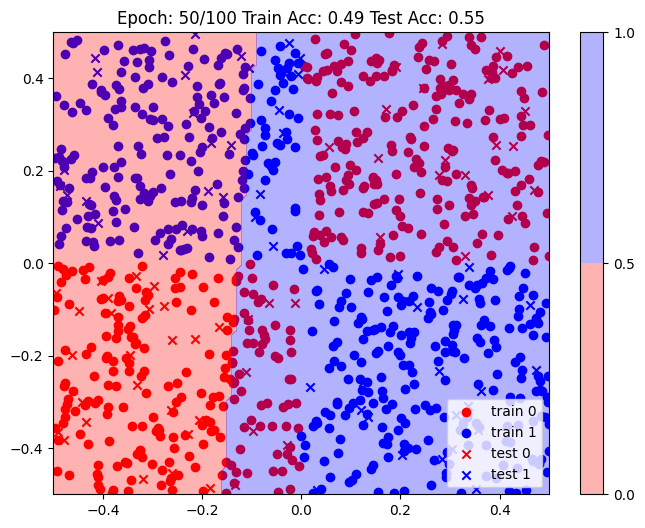

Epoch: 60/100 Loss: 0.6920
Epoch: 70/100 Loss: 0.6920
Epoch: 80/100 Loss: 0.6920
Epoch: 90/100 Loss: 0.6920
Epoch: 100/100 Loss: 0.6920


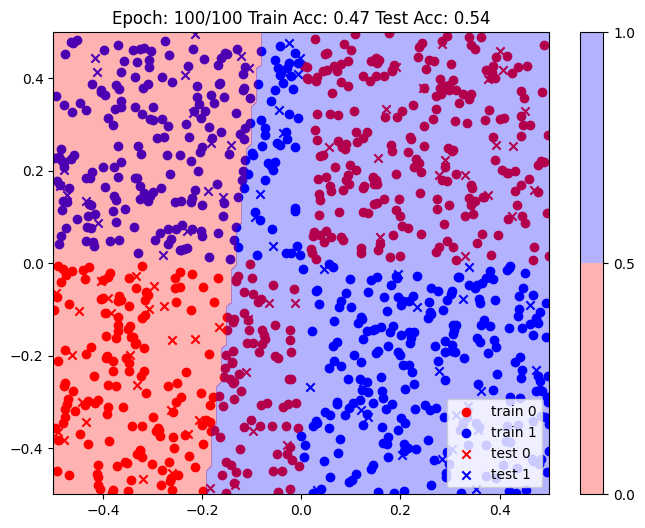

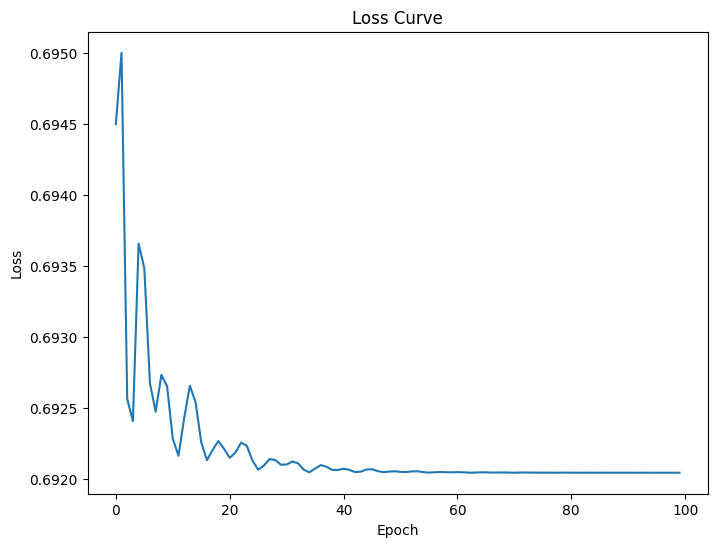

In [11]:
# Tests for Task 2.

if is_notebook():
    from lab02_utils import  train_model
    # Recall the linear model created for testing task 1     
    in_features = 2
    out_features = 2
    linear_model = nn.Linear(in_features, out_features)
    weight = linear_model.weight
    bias = linear_model.bias
    linear_model.forward = lambda x: linear_forward(x, weight, bias)    
    # TODO: Feel free to change the hyperparameters
    train_model(
        model=linear_model,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        loss_fn=nn.CrossEntropyLoss(),
        accuracy_fn=calculate_accuracy,
        num_epochs=100,
        print_every_epochs=10,
        evaluate_every_epochs=50,
        lr=0.1,
        temperature=None,
    )

    

## Task 3 -- 2-layer MLP

In [12]:
# --- TASK 3 --------------------------------------------------------------------------------------
# Build a basic neural network 

def build_two_layer_mlp(in_features: int = 2, out_features: int = 2, hidden_features: int = 4) -> nn.Module:
    """Builds a two-layer multi-layer perceptron (MLP) with ReLU activation functions in between.

    Args:
        in_features (int, optional): Number of input features. Defaults to 2.
        out_features (int, optional): Number of output features. Defaults to 2.
        hidden_features (int, optional): Number of hidden features. Defaults to 4.

    Returns:
        nn.Module: A PyTorch module representing the MLP.

    Notes:
        Use the `torch.nn` module to create `Linear` (with bias) and `ReLU` layers. We then wrap all layers using `Sequential`.
        Documentation for `Linear`: https://pytorch.org/docs/stable/generated/torch.nn.Linear.html.
        Documentation for `ReLU`: https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html.
        Documentation for `Sequential`: https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html.
    """
    # TODO: implement the two-layer MLP by creating two linear layers of appropriate size and a non-linear activation layer,
    # replacing `None` with the relevant PyTorch functions. See comments above for details.
    
    # Layer 1: Linear(in_features -> hidden_features)
    #
    #   This is the first transformation. It projects the input from
    #   in_features (2) dimensions into hidden_features (4) dimensions.
    #
    #   Why expand dimensions? More hidden neurons = more capacity to learn
    #   complex patterns. Each hidden neuron learns a different linear
    #   combination of the inputs, acting like a different "feature detector".
    #
    #   bias=True (default): each neuron has its own bias term, allowing it to
    #   shift its activation threshold independently of the input values.
    #
    #   Weight shape: (hidden_features, in_features) = (4, 2)
    #   Bias shape:   (hidden_features,)              = (4,)
    #   Output shape: (B, hidden_features)            = (B, 4)
    linearLayer1 = nn.Linear(in_features, hidden_features)

    # Activation: ReLU
    #
    #   ReLU stands for Rectified Linear Unit: f(x) = max(0, x)
    #   - Negative values are set to 0 (neuron "off")
    #   - Positive values pass through unchanged (neuron "on")
    #
    #   This is the KEY ingredient that makes the network non-linear.
    #   Without this, two stacked linear layers collapse into one linear layer:
    #     Linear(Linear(x)) = Linear(x)   <- still just a straight line
    #   ReLU breaks this collapse by introducing a non-linearity between layers.
    #
    #   For XOR specifically: ReLU allows the network to "bend" the decision
    #   boundary, which is necessary since XOR is not linearly separable.
    #
    #   Input/output shape: (B, hidden_features) = (B, 4), unchanged
    activationLayer = nn.ReLU()

    # Layer 2: Linear(hidden_features -> out_features)
    #
    #   This is the output layer. It projects the hidden representation
    #   from hidden_features (4) dimensions down to out_features (2) dimensions.
    #
    #   out_features = 2 because this is a binary classification task
    #   (class 0 and class 1). Each output neuron produces a score (logit)
    #   for its corresponding class.
    #
    #   The final prediction is the class with the higher logit (argmax).
    #   No softmax here — CrossEntropyLoss will handle that internally.
    #
    #   Weight shape: (out_features, hidden_features) = (2, 4)
    #   Bias shape:   (out_features,)                 = (2,)
    #   Output shape: (B, out_features)               = (B, 2)
    linearLayer2 = nn.Linear(hidden_features, out_features)
    
    return nn.Sequential(linearLayer1, activationLayer, linearLayer2)



Epoch: 10/1000 Loss: 0.6887
Epoch: 20/1000 Loss: 0.6736
Epoch: 30/1000 Loss: 0.6492
Epoch: 40/1000 Loss: 0.6253
Epoch: 50/1000 Loss: 0.5997
Epoch: 60/1000 Loss: 0.5741
Epoch: 70/1000 Loss: 0.5475
Epoch: 80/1000 Loss: 0.5208
Epoch: 90/1000 Loss: 0.4940
Epoch: 100/1000 Loss: 0.4671
Epoch: 110/1000 Loss: 0.4402
Epoch: 120/1000 Loss: 0.4140
Epoch: 130/1000 Loss: 0.3886
Epoch: 140/1000 Loss: 0.3654
Epoch: 150/1000 Loss: 0.3433
Epoch: 160/1000 Loss: 0.3211
Epoch: 170/1000 Loss: 0.2970
Epoch: 180/1000 Loss: 0.2771
Epoch: 190/1000 Loss: 0.2625
Epoch: 200/1000 Loss: 0.2512
Epoch: 210/1000 Loss: 0.2416
Epoch: 220/1000 Loss: 0.2333
Epoch: 230/1000 Loss: 0.2258
Epoch: 240/1000 Loss: 0.2191
Epoch: 250/1000 Loss: 0.2130
Epoch: 260/1000 Loss: 0.2073
Epoch: 270/1000 Loss: 0.2019
Epoch: 280/1000 Loss: 0.1969
Epoch: 290/1000 Loss: 0.1922
Epoch: 300/1000 Loss: 0.1878
Epoch: 310/1000 Loss: 0.1836
Epoch: 320/1000 Loss: 0.1797
Epoch: 330/1000 Loss: 0.1759
Epoch: 340/1000 Loss: 0.1723
Epoch: 350/1000 Loss: 0

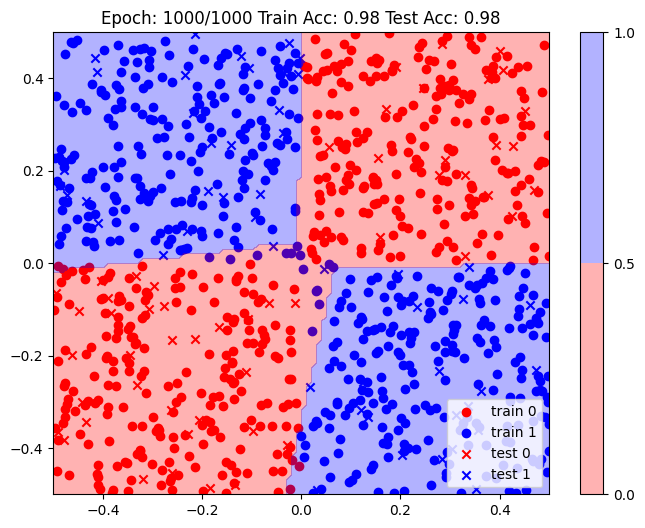

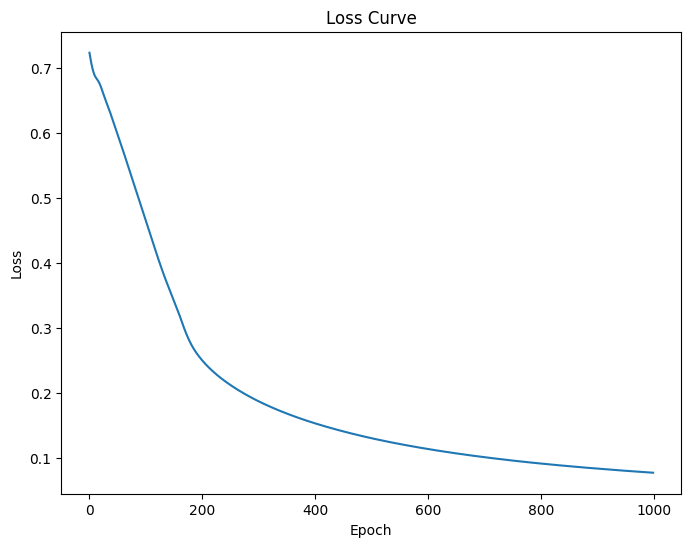

In [26]:
# Tests for Task 3.

if is_notebook():
    # testing out the 2-layer mlp
    # TODO: Feel free to change the hyperparameters
    train_model(
        model=build_two_layer_mlp(2, 2, 4),
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        loss_fn=nn.CrossEntropyLoss(),
        accuracy_fn=calculate_accuracy,
        num_epochs=1000,
        print_every_epochs=10,
        evaluate_every_epochs=1000,
        lr=0.01,
        temperature=None,
    )


## Task 4 -- Temperature-scaled Cross-entropy Loss

In [28]:
# --- TASK 4 --------------------------------------------------------------------------------------
# Define the loss function for the classification task 

def cross_entropy_loss(output: torch.Tensor, target: torch.Tensor, temperature: float) -> torch.Tensor:
    """Calculates the temperature scaled cross-entropy loss given `output` and `target`.

    Args:
        output (torch.Tensor): The unnormalized output from the model, of shape (B, C).
        target (torch.Tensor): The ground truth labels, of shape (B,).
        temperature (float): The temperature scaling for the softmax function.

    Returns:
        torch.Tensor: The loss value.

    Notes:
        See the lecture slides for the temperature scaling formula.
        The loss should be a single scalar tensor, averaged over the batch dimension.
        It is allowed to use `CrossEntropyLoss`, but we encourage you to challenge yourself by implementing it manually.
        Documentation for `CrossEntropyLoss`: https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html.
    """
    # TODO: implement the cross-entropy loss calculation.

    # Step 1: Scale logits by temperature
    #
    #   output contains raw logits (unnormalized scores), shape (B, C).
    #   Dividing by temperature T reshapes the distribution:
    #
    #   T < 1 (e.g. 0.1): logits become larger in magnitude → softmax output
    #                      becomes more "peaked" → model is more confident
    #                      → harder, more aggressive training signal
    #
    #   T = 1: standard softmax, no change
    #
    #   T > 1 (e.g. 10): logits become smaller → softmax output becomes
    #                     more uniform → model is less confident
    #                     → softer, more gentle training signal
    #
    #   Example with T=0.1:
    #     logits:          [2.0, 0.5]
    #     scaled (T=0.1):  [20.0, 5.0]  → softmax → [~1.0, ~0.0]  (very confident)
    #     scaled (T=1.0):  [2.0,  0.5]  → softmax → [0.82, 0.18]  (normal)
    #     scaled (T=10.0): [0.2,  0.05] → softmax → [0.54, 0.46]  (almost uniform)
    scaled = output / temperature

    # Step 2: Compute log-softmax for numerical stability
    #
    #   Naively computing log(softmax(x)) can cause numerical issues:
    #     softmax can produce very small values → log → -inf
    #
    #   torch.log_softmax combines the two operations in a numerically stable way
    #   using the log-sum-exp trick internally.
    #
    #   Formula: log_softmax(z_i) = z_i - log(Σ exp(z_j))
    #
    #   dim=1: apply softmax along the class dimension
    #   Output shape: (B, C), same as input
    log_probs = torch.log_softmax(scaled, dim=1)

    # Step 3: Extract the log-probability of the correct class for each sample
    #
    #   log_probs has shape (B, C). For each sample i, we only care about
    #   the log-probability assigned to the true class target[i].
    #
    #   torch.arange(len(target)) = [0, 1, 2, ..., B-1]  ← row indices
    #   target                    = [1, 0, 1, ...]        ← column indices
    #
    #   log_probs[rows, cols] picks one element per row:
    #     log_probs[0, target[0]], log_probs[1, target[1]], ...
    #
    #   Result shape: (B,) — one log-probability per sample
    #
    #   Example:
    #     log_probs = [[-0.2, -1.8],   sample 0
    #                  [-1.5, -0.3]]   sample 1
    #     target    = [1, 1]
    #     correct_log_probs = [-1.8, -0.3]
    correct_log_probs = log_probs[torch.arange(len(target)), target]

    # Step 4: Compute mean negative log-likelihood
    #
    #   Cross-entropy loss = -log(p_true_class)
    #   The negative sign turns log-probability (≤ 0) into a positive loss.
    #
    #   Perfect prediction:  log_prob → 0,    loss → 0      (good)
    #   Wrong prediction:    log_prob → -inf,  loss → +inf   (bad)
    #
    #   .mean() averages over the batch dimension B,
    #   giving a single scalar that represents the average loss per sample.
    return -correct_log_probs.mean()



Epoch: 10/1000 Loss: 1.8910
Epoch: 20/1000 Loss: 1.0450
Epoch: 30/1000 Loss: 0.8617
Epoch: 40/1000 Loss: 0.6744
Epoch: 50/1000 Loss: 0.6207
Epoch: 60/1000 Loss: 0.5923
Epoch: 70/1000 Loss: 0.5768
Epoch: 80/1000 Loss: 0.5635
Epoch: 90/1000 Loss: 0.5474
Epoch: 100/1000 Loss: 0.5287
Epoch: 110/1000 Loss: 0.5055
Epoch: 120/1000 Loss: 0.4783
Epoch: 130/1000 Loss: 0.4496
Epoch: 140/1000 Loss: 0.4215
Epoch: 150/1000 Loss: 0.3937
Epoch: 160/1000 Loss: 0.3667
Epoch: 170/1000 Loss: 0.3406
Epoch: 180/1000 Loss: 0.3161
Epoch: 190/1000 Loss: 0.2937
Epoch: 200/1000 Loss: 0.2738
Epoch: 210/1000 Loss: 0.2560
Epoch: 220/1000 Loss: 0.2404
Epoch: 230/1000 Loss: 0.2268
Epoch: 240/1000 Loss: 0.2150
Epoch: 250/1000 Loss: 0.2046
Epoch: 260/1000 Loss: 0.1954
Epoch: 270/1000 Loss: 0.1871
Epoch: 280/1000 Loss: 0.1798
Epoch: 290/1000 Loss: 0.1733
Epoch: 300/1000 Loss: 0.1673
Epoch: 310/1000 Loss: 0.1619
Epoch: 320/1000 Loss: 0.1570
Epoch: 330/1000 Loss: 0.1524
Epoch: 340/1000 Loss: 0.1482
Epoch: 350/1000 Loss: 0

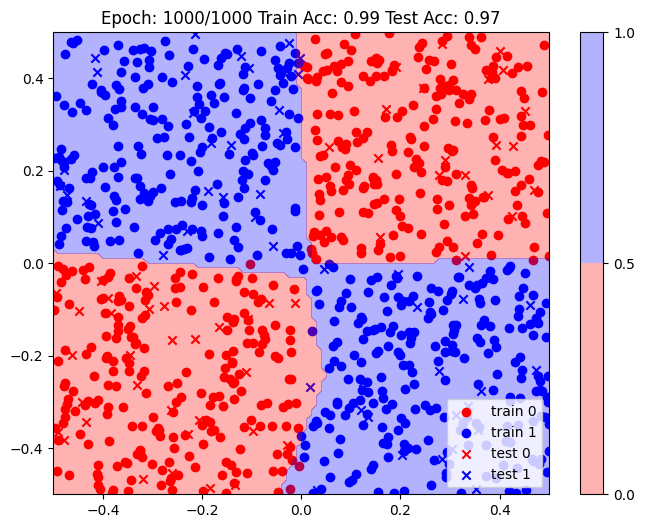

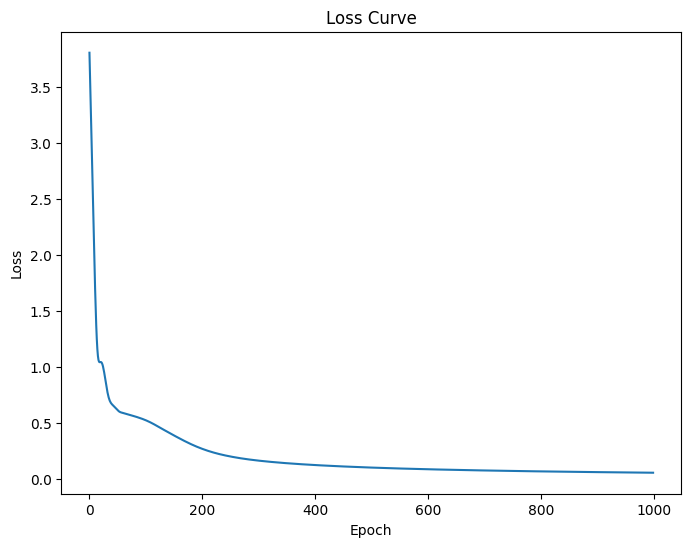

In [30]:
# Some tests for Task 4.

if is_notebook():
    # TODO: Feel free to change the hyperparameters
    train_model(
        model=build_two_layer_mlp(2, 2, 4),
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        loss_fn=cross_entropy_loss,
        accuracy_fn=calculate_accuracy,
        num_epochs=1000,
        print_every_epochs=10,
        evaluate_every_epochs=1000,
        lr=0.01,
        temperature=0.1,
    )

## Task 5 -- Minimum Layers for XOR 

In [33]:
# --- TASK 5 -----------------------------------------------------------------------------------------------------------
# TODO: Set this constant to the minimum number of layers required to solve the XOR problem using an MLP theoretically.
# You are welcome to borrow code from previous tasks to verify your answer.
# Be sure not to directly modify or accidentally overwrite Task 1-4 upon submission. 
# Note that we will not run your code. We'll only check the value of this constant.
MINIMUM_NUMBER_OF_LAYERS_TO_SOLVE_XOR_PROBLEM: int = 2

#
# The XOR problem requires a minimum of 2 layers (1 hidden layer + 1 output layer)
# to solve. This is not just an empirical observation — it is a mathematical necessity.
#
# ---------------------------------------------------------------------------------
# WHY 1 LAYER IS PROVABLY INSUFFICIENT
# ---------------------------------------------------------------------------------
#
# A single linear layer computes: y = xW + b
# This is an affine transformation — it can only produce linear decision boundaries
# (hyperplanes in the input space). No matter how you choose W and b, you cannot
# draw a straight line that correctly separates the four XOR points:
#
#     (-,-) → 0    (+,-) → 1
#     (-,+) → 1    (+,+) → 0
#
#   Class 1 lives in the 2nd and 4th quadrants (off-diagonal).
#   Class 0 lives in the 1st and 3rd quadrants (diagonal).
#   No single straight line separates them — XOR is linearly non-separable.
#
# Minsky & Papert formally proved this in their 1969 book "Perceptrons",
# which famously caused a decade-long AI winter by demonstrating the fundamental
# limitation of single-layer networks.
#
# ---------------------------------------------------------------------------------
# WHY 2 LAYERS ARE SUFFICIENT
# ---------------------------------------------------------------------------------
#
# Adding one hidden layer with a non-linear activation (e.g. ReLU) fundamentally
# changes what the network can represent.
#
# Intuitively, the hidden layer "folds" the input space:
#   - Each hidden neuron draws its own linear boundary (a line in 2D)
#   - ReLU selectively "activates" regions of the input space
#   - Together, multiple neurons carve the space into regions
#   - The output layer then draws one final line in this transformed space
#
# What was non-separable in the original space becomes separable in the
# hidden representation space. The network essentially learns a new coordinate
# system where XOR is easy.
#
# This is the core insight behind deep learning: layers don't just transform data,
# they learn progressively more abstract representations of it.
#
# ---------------------------------------------------------------------------------
# THE UNIVERSAL APPROXIMATION THEOREM
# ---------------------------------------------------------------------------------
#
# Cybenko (1989) and Hornik (1991) proved that a neural network with just ONE
# hidden layer containing enough neurons can approximate any continuous function
# to arbitrary precision — including XOR.
#
# This is the theoretical foundation that justifies the entire field of deep learning.
# Yann LeCun (Turing Award 2018) described it as the result that "proved neural
# networks were not just a curiosity, but a universal computational framework."
#
# However, "sufficient" does not mean "efficient":
#   - 2 layers can solve XOR in theory with enough hidden neurons
#   - But deeper networks can solve harder problems with exponentially fewer neurons
#   - This is why Hinton, LeCun, and Bengio (the "Godfathers of Deep Learning")
#     advocated for DEEP architectures over wide shallow ones
#
# ---------------------------------------------------------------------------------
# THE HISTORICAL SIGNIFICANCE
# ---------------------------------------------------------------------------------
#
# XOR is deceptively simple, but its implications reshaped the field:
#
#   1969 — Minsky & Papert prove single-layer perceptrons cannot solve XOR.
#           → First AI winter begins. Neural network research nearly dies.
#
#   1986 — Rumelhart, Hinton & Williams publish backpropagation.
#           → Multi-layer networks can now be trained efficiently.
#           → XOR is immediately solved. Neural networks are reborn.
#
#   2012 — Hinton's AlexNet wins ImageNet by a massive margin.
#           → Deep learning era begins. The lesson: depth matters.
#
#   Today — GPT-4, Gemini, Claude are all descendants of the same idea:
#           stack enough layers with non-linearities, train with backprop,
#           and the network learns to represent arbitrarily complex functions.
#
# The answer "2" is therefore not just the solution to a homework problem.
# It is the minimum proof-of-concept that broke open the modern AI revolution.